<a href="https://colab.research.google.com/github/Kei300/IA-Python-Libraries-Statistics/blob/main/5_an%C3%A1lisis_estad%C3%ADstico_calidad_del_aire_cdmx_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis Estadístico Calidad del Aire CDMX

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##ETL


In [161]:
df_2026 = pd.read_csv('/content/contaminantes_2026.csv', header=9, on_bad_lines='skip')
df_2025 = pd.read_csv('/content/contaminantes_2025.csv', header=9, on_bad_lines='skip')
df_2024 = pd.read_csv('/content/contaminantes_2024.csv', header=9, on_bad_lines='skip')

df_2024.rename(columns={'value': 'valor'}, inplace=True)
df_2025.rename(columns={'value': 'valor'}, inplace=True)
df_2026.rename(columns={'value': 'valor'}, inplace=True)

df_raw = pd.concat([df_2024, df_2025, df_2026], ignore_index=True)
df_raw.head(10)

,date,id_station,id_parameter,valor,unit
0,2024-01-01 01:00:00,ACO,CO,NaN,15.0
1,2024-01-01 01:00:00,ACO,NO,NaN,1.0
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.0
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.0
4,2024-01-01 01:00:00,ACO,O3,NaN,1.0
5,2024-01-01 01:00:00,ACO,PM10,NaN,2.0
6,2024-01-01 01:00:00,ACO,SO2,NaN,1.0
7,2024-01-01 01:00:00,AJM,CO,0.23,15.0
8,2024-01-01 01:00:00,AJM,NO,0.00,1.0
9,2024-01-01 01:00:00,AJM,NO2,10.00,1.0


In [162]:
df = df_raw.copy()

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['valor'] = pd.to_numeric(df['valor'], errors='coerce')

df.dropna(subset=['date', 'id_parameter', 'valor'], inplace=True)

df.sort_values(by='date', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

In [163]:
display(df.info())

duplicated_rows = df.duplicated().sum()
print(f"\n Filas duplicadas: {duplicated_rows}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2981542 entries, 0 to 2981541
Data columns (total 5 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   id_station    object        
 2   id_parameter  object        
 3   valor         float64       
 4   unit          float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 113.7+ MB


None


 Filas duplicadas: 0


In [164]:
unique_parameters = df['id_parameter'].unique()
print(f'Contaminantes: {unique_parameters}')

Contaminantes: ['CO' 'O3' 'PM10' 'PM2.5' 'PMCO' 'NO' 'NO2' 'NOX' 'SO2']


##Calcular Medidas de Tendencia Central

Media

In [165]:
media_general_contaminante = df.groupby('id_parameter')['valor'].mean().reset_index()
print("\nMEDIA GENERAL POR CONTAMINANTE ")
print(media_general_contaminante.to_string(index=False))


MEDIA GENERAL POR CONTAMINANTE 
id_parameter     valor
          CO  0.519463
          NO 13.182362
         NO2 23.112680
         NOX 36.673457
          O3 32.697506
        PM10 41.884078
       PM2.5 20.472827
        PMCO 17.916185
         SO2  3.016668


In [166]:
medias = []

for fecha in [2024, 2025, 2026]:
    df_fecha = df[df['date'].dt.year == fecha]

    media_contaminante_fecha = df_fecha.groupby('id_parameter')['valor'].mean().reset_index()
    medias.append(media_contaminante_fecha)

    print(f"Media por Contaminante en {fecha}:")
    print(media_contaminante_fecha.to_string(index=False))
    print("\n" + "-"*40 + "\n")

Media por Contaminante en 2024:
id_parameter     valor
          CO  0.472702
          NO 13.756513
         NO2 23.382838
         NOX 37.215829
          O3 33.057411
        PM10 43.499788
       PM2.5 20.549143
        PMCO 19.450945
         SO2  2.588296

----------------------------------------

Media por Contaminante en 2025:
id_parameter     valor
          CO  0.524322
          NO 11.574989
         NO2 21.956945
         NOX 34.220856
          O3 32.509778
        PM10 38.853138
       PM2.5 19.630292
        PMCO 16.023970
         SO2  2.818824

----------------------------------------

Media por Contaminante en 2026:
id_parameter     valor
          CO  0.789015
          NO 20.404501
         NO2 29.539319
         NOX 49.763884
          O3 31.578159
        PM10 52.091124
       PM2.5 25.612020
        PMCO 19.946565
         SO2  7.004350

----------------------------------------



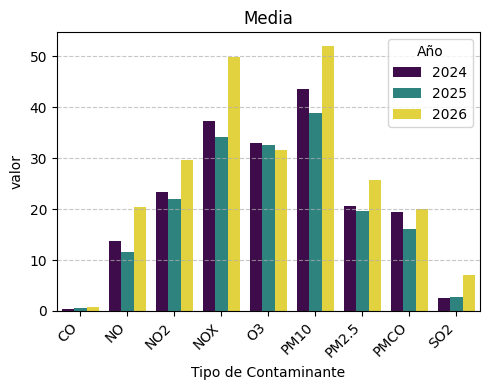

In [167]:
years = [2024, 2025, 2026]
corrected_medias = []
for i, df_mean in enumerate(medias):
    df_mean_copy = df_mean.copy()
    df_mean_copy['year'] = years[i]
    corrected_medias.append(df_mean_copy)

df_plot_means = pd.concat(corrected_medias)

plt.figure(figsize=(5, 4))
sns.barplot(data=df_plot_means, x='id_parameter', y='valor', hue='year', palette='viridis')
plt.title('Media')
plt.xlabel('Tipo de Contaminante')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Año')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Moda

In [168]:
moda_general_contaminante = df.groupby('id_parameter')['valor'].apply(lambda x: x.mode().tolist() if not x.mode().empty else None).reset_index()
print("\nMODA POR CONTAMINANTE ")
print(moda_general_contaminante.to_string(index=False))


MODA POR CONTAMINANTE 
id_parameter  valor
          CO  [0.3]
          NO  [1.0]
         NO2 [14.0]
         NOX [14.0]
          O3  [2.0]
        PM10 [28.0]
       PM2.5 [13.0]
        PMCO  [7.0]
         SO2  [1.0]


In [169]:
for year in [2024, 2025, 2026]:
    df_year_filtered = df[df['date'].dt.year == year]

    moda_contaminante_fecha = df_year_filtered.groupby('id_parameter')['valor'].apply(lambda x: x.mode().tolist() if not x.mode().empty else None).reset_index()

    print(f"\nModa por Contaminante en {year}:")
    print(moda_contaminante_fecha.to_string(index=False))
    print("\n" + "-"*40 + "\n")


Moda por Contaminante en 2024:
id_parameter  valor
          CO [0.25]
          NO  [1.0]
         NO2 [14.0]
         NOX [14.0]
          O3  [1.0]
        PM10 [26.0]
       PM2.5 [15.0]
        PMCO  [6.0]
         SO2  [1.0]

----------------------------------------


Moda por Contaminante en 2025:
id_parameter  valor
          CO  [0.3]
          NO  [1.0]
         NO2 [15.0]
         NOX [14.0]
          O3  [2.0]
        PM10 [23.0]
       PM2.5 [13.0]
        PMCO  [7.0]
         SO2  [1.0]

----------------------------------------


Moda por Contaminante en 2026:
id_parameter        valor
          CO       [0.37]
          NO        [1.0]
         NO2       [25.0]
         NOX       [22.0]
          O3        [3.0]
        PM10       [37.0]
       PM2.5 [22.0, 23.0]
        PMCO        [7.0]
         SO2        [2.0]

----------------------------------------



mediana

In [170]:
mediana_general_contaminante = df.groupby('id_parameter')['valor'].median().reset_index()
print("\n MEDIANA GENERAL POR CONTAMINANTE ")
print(mediana_general_contaminante.to_string(index=False))



 MEDIANA GENERAL POR CONTAMINANTE 
id_parameter  valor
          CO   0.41
          NO   3.00
         NO2  21.00
         NOX  26.00
          O3  25.00
        PM10  37.00
       PM2.5  18.00
        PMCO  15.00
         SO2   1.00


In [171]:
medianas_anuales = []

for year in [2024, 2025, 2026]:
    df_year_filtered = df[df['date'].dt.year == year]

    mediana_contaminante_fecha = df_year_filtered.groupby('id_parameter')['valor'].median().reset_index()
    medianas_anuales.append(mediana_contaminante_fecha)

    print(f"\nMediana por Contaminante en {year}:")
    print(mediana_contaminante_fecha.to_string(index=False))
    print("\n" + "-"*40 + "\n")


Mediana por Contaminante en 2024:
id_parameter  valor
          CO   0.36
          NO   3.00
         NO2  21.00
         NOX  25.00
          O3  26.00
        PM10  38.00
       PM2.5  18.00
        PMCO  17.00
         SO2   1.00

----------------------------------------


Mediana por Contaminante en 2025:
id_parameter  valor
          CO   0.44
          NO   3.00
         NO2  20.00
         NOX  25.00
          O3  25.00
        PM10  34.00
       PM2.5  18.00
        PMCO  13.00
         SO2   1.00

----------------------------------------


Mediana por Contaminante en 2026:
id_parameter  valor
          CO   0.64
          NO   4.00
         NO2  27.00
         NOX  33.00
          O3  23.00
        PM10  46.00
       PM2.5  23.00
        PMCO  16.00
         SO2   3.00

----------------------------------------



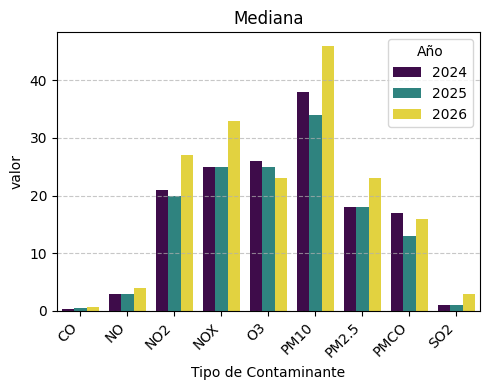

In [172]:
years = [2024, 2025, 2026]
corrected_medianas = []
for i, df_mediana in enumerate(medianas_anuales):
    df_mediana_copy = df_mediana.copy()
    df_mediana_copy['year'] = years[i]
    corrected_medianas.append(df_mediana_copy)

df_plot_medianas = pd.concat(corrected_medianas)

plt.figure(figsize=(5, 4))
sns.barplot(data=df_plot_medianas, x='id_parameter', y='valor', hue='year', palette='viridis')
plt.title('Mediana')
plt.xlabel('Tipo de Contaminante')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Año')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Calcular Medidad de Dispersión

varianza

In [173]:
varianza_general_contaminante = df.groupby('id_parameter')['valor'].var().reset_index()
print("\n VARIANZA GENERAL POR CONTAMINANTE ")
print(varianza_general_contaminante.to_string(index=False))


 VARIANZA GENERAL POR CONTAMINANTE 
id_parameter       valor
          CO    0.173510
          NO  747.883103
         NO2  186.191603
         NOX 1288.710596
          O3  798.295606
        PM10  781.734973
       PM2.5  169.165173
        PMCO  205.057289
         SO2   34.261859


In [178]:
for year in [2024, 2025, 2026]:
    df_year_filtered = df[df['date'].dt.year == year]

    varianza_contaminante_fecha = df_year_filtered.groupby('id_parameter')['valor'].var().reset_index()
    print(f"\nVarianza por Contaminante en {year}:")
    print(varianza_contaminante_fecha.to_string(index=False))
    print("\n" + "-"*40 + "\n")


Varianza por Contaminante en 2024:
id_parameter       valor
          CO    0.171310
          NO  830.662811
         NO2  195.041476
         NOX 1417.297143
          O3  803.708940
        PM10  824.320885
       PM2.5  176.135603
        PMCO  214.489183
         SO2   23.261640

----------------------------------------


Varianza por Contaminante en 2025:
id_parameter      valor
          CO   0.144799
          NO 557.967896
         NO2 160.485809
         NOX 994.384687
          O3 784.402187
        PM10 667.185628
       PM2.5 138.493721
        PMCO 185.678479
         SO2  27.221226

----------------------------------------


Varianza por Contaminante en 2026:
id_parameter       valor
          CO    0.310468
          NO 1436.679042
         NO2  259.321716
         NOX 2250.227711
          O3  854.629433
        PM10 1100.082003
       PM2.5  294.855566
        PMCO  224.965904
         SO2  132.455025

----------------------------------------



desviación estándar

In [175]:
desviacion_estandar_general_contaminante = df.groupby('id_parameter')['valor'].std().reset_index()
print("\n DESVIACIÓN ESTÁNDAR POR CONTAMINANTE")
print(desviacion_estandar_general_contaminante.to_string(index=False))


 DESVIACIÓN ESTÁNDAR POR CONTAMINANTE
id_parameter     valor
          CO  0.416546
          NO 27.347451
         NO2 13.645204
         NOX 35.898616
          O3 28.254125
        PM10 27.959524
       PM2.5 13.006351
        PMCO 14.319822
         SO2  5.853363


In [176]:
for year in [2024, 2025, 2026]:
    df_year_filtered = df[df['date'].dt.year == year]
    ds_contaminante_fecha = df_year_filtered.groupby('id_parameter')['valor'].std().reset_index()
    print(f"\n DS por Contaminante en {year}:")
    print(ds_contaminante_fecha.to_string(index=False))
    print("\n" + "-"*40 + "\n")


 DS por Contaminante en 2024:
id_parameter     valor
          CO  0.413897
          NO 28.821222
         NO2 13.965725
         NOX 37.647007
          O3 28.349761
        PM10 28.710989
       PM2.5 13.271609
        PMCO 14.645449
         SO2  4.823032

----------------------------------------


 DS por Contaminante en 2025:
id_parameter     valor
          CO  0.380524
          NO 23.621344
         NO2 12.668299
         NOX 31.533866
          O3 28.007181
        PM10 25.829937
       PM2.5 11.768336
        PMCO 13.626389
         SO2  5.217396

----------------------------------------


 DS por Contaminante en 2026:
id_parameter     valor
          CO  0.557197
          NO 37.903549
         NO2 16.103469
         NOX 47.436565
          O3 29.234046
        PM10 33.167484
       PM2.5 17.171359
        PMCO 14.998863
         SO2 11.508911

----------------------------------------



#Graficar distribuciones

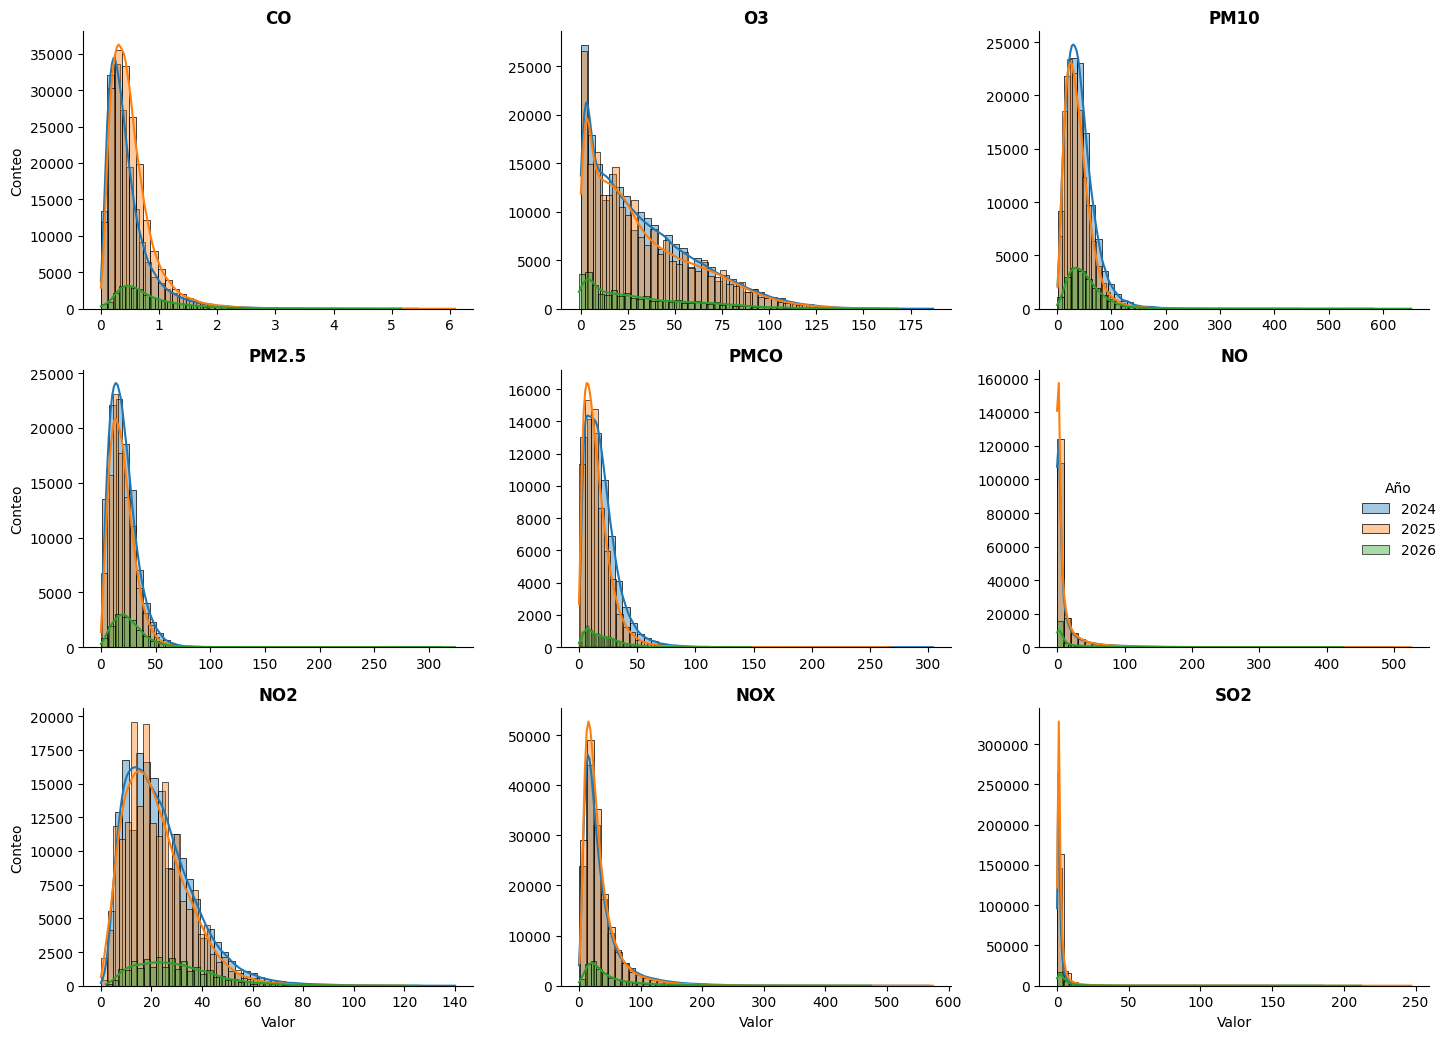

In [177]:
df['year'] = df['date'].dt.year.astype(str)

g = sns.FacetGrid(
    data=df,
    col="id_parameter",
    hue="year",
    palette="tab10",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=3.5,
    aspect=1.3
)

g.map_dataframe(
    sns.histplot,
    x="valor",
    kde=True,
    bins=50,
    alpha=0.4
)

g.set_titles(col_template="{col_name}", size=12, weight='bold')
g.set_axis_labels("Valor", "Conteo")
g.add_legend(title="Año", adjust_subtitles=True)

plt.tight_layout()
plt.show()